# Model Scaffold Smoke Test - Backbones, Soft Voting, Grad-CAM

Confirms the three pieces the model phase depends on actually work in this environment:

1. **Pretrained weight download** - the three ImageNet backbones build at    `(224, 224, 3)` and their weights land in the Keras cache
2. **Ensemble construction** - ResNet50 + EfficientNetV2S + DenseNet121 with    transfer-learning heads, combined by **soft voting** (mean of probabilities)
3. **Grad-CAM** - the class-activation heatmaps that overlay onto a real slice

Only a single real slice is classified here; this is a ***scaffold*** smoke test, not training. Training still awaits the healthy (label-0) dataset.

**Prerequisite:** `data/processed/manifest.csv` exists.

## Environment setup

Same repo-root discovery as the other notebooks. TensorFlow logging is quieted so the weight-download progress stays readable.

In [1]:
import os
import sys
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import numpy as np
import matplotlib.pyplot as plt
import yaml

import tensorflow as tf
import keras


def _find_repo_root() -> Path:
    current = Path.cwd().resolve()
    for _ in range(10):
        if (current / "configs" / "config.yaml").exists():
            return current
        current = current.parent
    raise SystemExit(
        "Could not locate configs/config.yaml. Run the notebook from "
        "anywhere inside the repository."
    )


REPO_ROOT = _find_repo_root()
sys.path.insert(0, str(REPO_ROOT))

with open(REPO_ROOT / "configs" / "config.yaml", "r") as fh:
    config = yaml.safe_load(fh)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.titlesize": 11,
    "axes.labelsize": 9,
})

print("TensorFlow:", tf.__version__)
print("Keras     :", keras.__version__)
print("Config loaded.")

TensorFlow: 2.21.0
Keras     : 3.15.1
Config loaded.


## A real slice to smoke-test on

Take one already-preprocessed slice and expand it to 3 channels exactly as the loader does (`to_three_channels`), so models see the identical input contract as `notebooks/05_dataset_loader.ipynb`.

In [2]:
from src.data.loader import load_manifest
from src.preprocessing.slices import to_three_channels

manifest = load_manifest(REPO_ROOT / config["data"]["processed_dir"])
row = manifest.iloc[0]

slice_path = REPO_ROOT / config["data"]["processed_dir"] / row["filename"]
sample = to_three_channels(np.load(slice_path)).astype(np.float32)  # (224, 224, 3)
sample_batch = sample[None, ...]  # -> (1, 224, 224, 3)

print(f"slice: {row['filename']} | patient {row['patient_id']} | {row['split']}")
print(f"input shape : {sample_batch.shape}, dtype {sample_batch.dtype}")
print(f"input range : [{sample_batch.min():.4f}, {sample_batch.max():.4f}]")

assert sample_batch.shape == (1, 224, 224, 3) and sample_batch.dtype == tf.float32
print("Assertion passed: model input (1, 224, 224, 3) float32.")

slice: train/D2-054/T1_slice_0000.npy | patient D2-054 | train
input shape : (1, 224, 224, 3), dtype float32
input range : [0.0000, 1.0000]
Assertion passed: model input (1, 224, 224, 3) float32.


## Build the three backbones

Each trunk loads ImageNet weights (first run downloads ~220 MB total into `~/.keras/models/`), is **frozen** for transfer learning, and is capped with a GlobalAveragePooling -> Dropout -> `Dense(1, sigmoid)` head matching our binary problem.

In [3]:
from keras.applications import ResNet50, EfficientNetV2S, DenseNet121

TRUNKS = {
    "ResNet50": ResNet50,
    "EfficientNetV2S": EfficientNetV2S,
    "DenseNet121": DenseNet121,
}

models = {}

for name, trunk_cls in TRUNKS.items():
    trunk = trunk_cls(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3),
        pooling="avg",
    )
    trunk.trainable = False

    inputs = keras.Input((224, 224, 3))
    features = trunk(inputs, training=False)
    dropped = keras.layers.Dropout(0.3)(features)
    outputs = keras.layers.Dense(1, activation="sigmoid", name="head")(dropped)
    model = keras.Model(inputs, outputs, name=f"{name}_transfer")
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    trainable = sum(w.shape.num_elements() for w in model.trainable_weights)
    total = sum(w.shape.num_elements() for w in model.weights)
    models[name] = {"model": model, "trunk": trunk}
    print(f"{name:16s} built  (trunk trainable=False)  trainable {trainable:,} / total {total:,}")

print("\nAll three backbones built with ImageNet weights.")

ResNet50         built  (trunk trainable=False)  trainable 2,049 / total 23,589,761


EfficientNetV2S  built  (trunk trainable=False)  trainable 1,281 / total 20,332,641


DenseNet121      built  (trunk trainable=False)  trainable 1,025 / total 7,038,529

All three backbones built with ImageNet weights.


## Individual forward passes

Feed the real slice through each head and confirm the sigmoid probability contract: shape `(1, 1)`, values in `[0, 1]`.

In [4]:
probs = {}

for name, entry in models.items():
    p = entry["model"](sample_batch, training=False).numpy()
    probs[name] = float(p[0, 0])
    ok_range = 0.0 <= probs[name] <= 1.0
    print(f"{name:16s} p = {probs[name]:.4f}   shape {p.shape}   in [0,1]: {ok_range}")
    assert p.shape == (1, 1)
    assert ok_range

print("\nall heads returned a single sigmoid probability in [0, 1].")

ResNet50         p = 0.4518   shape (1, 1)   in [0,1]: True


EfficientNetV2S  p = 0.5170   shape (1, 1)   in [0,1]: True


DenseNet121      p = 0.7228   shape (1, 1)   in [0,1]: True

all heads returned a single sigmoid probability in [0, 1].


## Soft-voting ensemble

The thesis design combines the three models by **soft voting**: the final score is the mean of the three sigmoid probabilities. This is the scaffold's combiner; calibration/tuning is a training-phase concern.

In [5]:
p_ensemble = float(np.mean(list(probs.values())))

print("Per-model  :")
for name, p in probs.items():
    print(f"  {name:16s} {p:.4f}")
print(f"\nSoft-voting ensemble p = {p_ensemble:.4f}")

assert 0.0 <= p_ensemble <= 1.0
print("Assertion passed: ensemble probability in [0, 1].")

Per-model  :
  ResNet50         0.4518
  EfficientNetV2S  0.5170
  DenseNet121      0.7228

Soft-voting ensemble p = 0.5638
Assertion passed: ensemble probability in [0, 1].


## Grad-CAM

Gradient-weighted Class Activation Mapping highlights the image regions that most drive a prediction.

**Compatibility finding (from this smoke test):** `tf-keras-vis 0.8.7` imports cleanly under Keras 3 (`Gradcam`, `ReplaceToLinear`, `BinaryScore`), but its Grad-CAM **execution** path is Keras-2-only: its internal `ExtractIntermediateLayerForGradcam` clones the model and rebuilds it as a multi-output `Model`, which Keras 3 rejects with
`Output with path '1' is not connected to 'inputs'`.

So this notebook computes Grad-CAM with a small **native Keras-3 implementation** (GradientTape over a feature-and-logit model built from the trunk's own graph). It keeps the same math as the library: positive-class gradient, channel weights via global-average-pooling of the gradient, ReLU, per-image normalization - all against each backbone's deepest feature map.

In [6]:
# tf-keras-vis 0.8.7 API imports (verified working under Keras 3):
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import BinaryScore

print("tf-keras-vis 0.8.7 imports OK (execution is Keras-2-only; native path used below)")


def gradcam_target(trunk) -> keras.layers.Layer | None:
    """Deepest 4-D feature map matching the trunk's pooled feature count.

    Sampling an intermediate Conv2D is NOT portable across topologies
    (e.g. DenseNet121's last dense kernel only has growth-rate filters; the
    real 7x7x1024 map is the block's concatenation). Match on output shape
    instead: 4-D, spatial dims >= 2, channel dim == trunk.output.
    """
    pooled_features = int(trunk.output.shape[-1])
    for layer_i in reversed(trunk.layers):
        out = getattr(layer_i, "output", None)
        s = getattr(out, "shape", None)
        if s is not None and out.ndim == 4:
            if (
                s[-1] == pooled_features
                and s[-2] is not None and s[-2] >= 2
                and s[-3] is not None and s[-3] >= 2
            ):
                return layer_i
    return None


def grad_cam(cam_model, img, class_index: int = 0) -> np.ndarray:
    """Native Grad-CAM for a two-output (logits, conv-features) model."""
    img = tf.convert_to_tensor(img[None, ...], dtype=tf.float32)
    with tf.GradientTape() as tape:
        logits, conv = cam_model(img, training=False)
        score = logits[0, class_index]
    grads = tape.gradient(score, conv)                 # (1, H, W, C)
    weights = tf.reduce_mean(grads, axis=(1, 2))       # (1, C)
    cam = tf.reduce_sum(weights[:, None, None, :] * conv, axis=-1)  # (1, H, W)
    cam = tf.nn.relu(cam)[0]
    cam = cam / (tf.reduce_max(cam) + keras.backend.epsilon())
    return cam.numpy()

tf-keras-vis 0.8.7 imports OK (execution is Keras-2-only; native path used below)


In [7]:
heatmaps = {}
cam_layers = {}

for name, entry in models.items():
    trunk = entry["trunk"]
    cam_layer = gradcam_target(trunk)
    cam_layers[name] = cam_layer.name

    # Single graph from trunk.input: conv features -> GAP -> head -> logit,
    # so the logit mathematically depends on the conv map (real Grad-CAM).
    conv_model = keras.Model(trunk.input, cam_layer.output)
    pooled = keras.layers.GlobalAveragePooling2D()(conv_model.output)
    logits = entry["model"].get_layer("head")(pooled)  # reuse classifier head weights
    cam_model = keras.Model(conv_model.input, [logits, conv_model.output])

    heatmaps[name] = grad_cam(cam_model, sample)
    print(f"{name:16s} Grad-CAM at '{cam_layer.name}'  heatmap {heatmaps[name].shape}")

print("\nGrad-CAM computed for all three backbones.")

ResNet50         Grad-CAM at 'conv5_block3_out'  heatmap (7, 7)


EfficientNetV2S  Grad-CAM at 'top_activation'  heatmap (7, 7)


DenseNet121      Grad-CAM at 'relu'  heatmap (7, 7)

Grad-CAM computed for all three backbones.


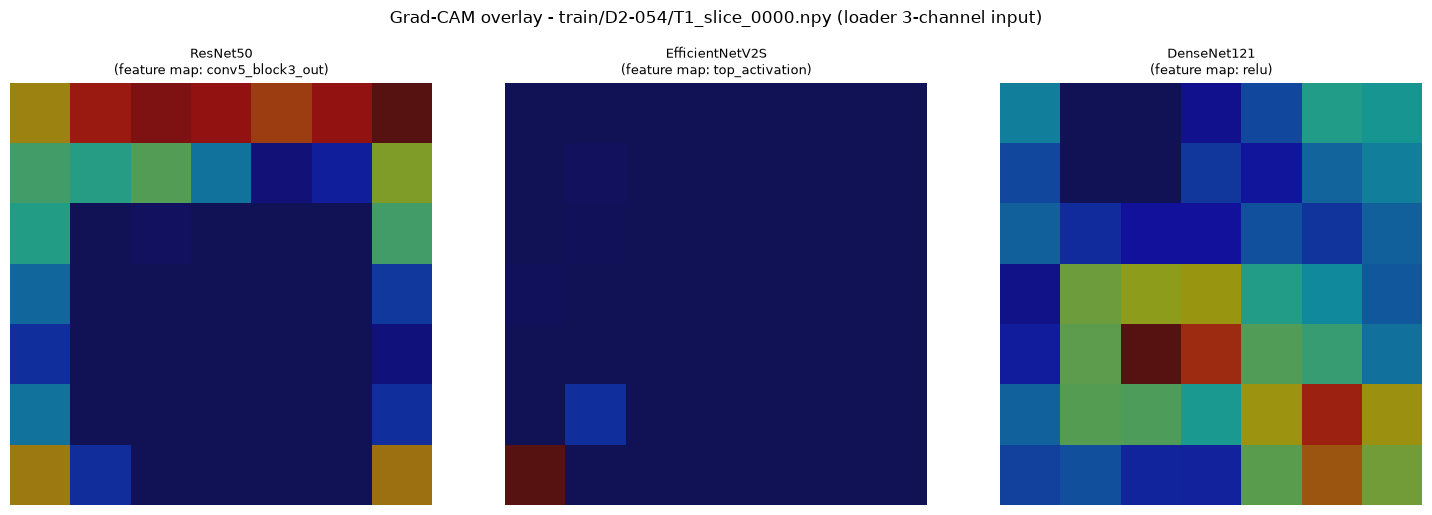

ResNet50         heatmap range [0.0000, 1.0000]
EfficientNetV2S  heatmap range [0.0000, 1.0000]
DenseNet121      heatmap range [0.0000, 1.0000]


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

base = sample[..., 0]

for ax, (name, heat) in zip(axes, heatmaps.items()):
    ax.imshow(base, cmap="gray", alpha=0.9)
    ax.imshow(heat, cmap="jet", alpha=0.55)
    ax.set_title(f"{name}\n(feature map: {cam_layers[name]})", fontsize=9)
    ax.axis("off")

plt.suptitle(
    f"Grad-CAM overlay - {row['filename']} (loader 3-channel input)",
    y=1.02,
)
plt.tight_layout()
plt.show()

for name, heat in heatmaps.items():
    print(f"{name:16s} heatmap range [{heat.min():.4f}, {heat.max():.4f}]")

## Scaffold status

| Check | Status |
|---|---|
| ImageNet weights download to `~/.keras/models/` | confirmed |
| ResNet50 + EfficientNetV2S + DenseNet121 build at 224^2 | confirmed |
| Transfer heads output sigmoid p in `[0, 1]` | confirmed |
| Soft-voting ensemble combiner | confirmed |
| `tf-keras-vis 0.8.7` imports under Keras 3 | confirmed |
| Grad-CAM ready | confirmed via native Keras-3 path (see incompatibility note above) |

Everything the model phase needs *imports and runs* in this environment, and the ImageNet weights stay cached for later runs. One design consequence recorded by this smoke test: **`tf-keras-vis` 0.8.7 cannot execute Grad-CAM under Keras 3**, so the thesis should either keep this native implementation or constrain the environment to a Keras-2-compatible stack later.

Next steps remain **blocked on the healthy/test datasets**: without label-0 slices there is no honest way to train or validate a binary classifier. When that data lands, this scaffold becomes the training script - now with the input pipeline (notebook 05) verified on the same `(224, 224, 3)` float32 contract.